<a href="https://colab.research.google.com/github/Sadafnasim/Tomato-Disease-Doctor/blob/main/tomato_leaf_disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#!pip install tensorflow


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing import image
import os


In [6]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
from google.colab import files
uploaded = files.upload()  # Upload the ZIP file manually


KeyboardInterrupt: 

In [4]:
import zipfile

# Path to your uploaded zip file
zip_file_path = "/content/archive (1).zip"
extract_path = "/content/dataset"  # You can change the destination path if needed

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)


FileNotFoundError: [Errno 2] No such file or directory: '/content/archive (1).zip'

In [ ]:
import os

data_dir = "/content/dataset/tomato/train"  # Adjust if your structure is different

print("📂 Categories:")
for folder in os.listdir(data_dir):
    print("-", folder)


📂 Categories:
- Tomato___Early_blight
- Tomato___Spider_mites Two-spotted_spider_mite
- Tomato___Bacterial_spot
- Tomato___Septoria_leaf_spot
- Tomato___healthy
- Tomato___Late_blight
- Tomato___Leaf_Mold
- Tomato___Tomato_mosaic_virus
- Tomato___Tomato_Yellow_Leaf_Curl_Virus
- Tomato___Target_Spot


In [8]:
import os

data_dir = "/content/drive/MyDrive/tomato/train"  # Adjust if your structure is different

print("📂 Categories:")
for folder in os.listdir(data_dir):
    print("-", folder)


📂 Categories:
- Tomato___Septoria_leaf_spot
- Tomato___Leaf_Mold
- Tomato___Tomato_mosaic_virus
- Tomato___healthy
- Tomato___Spider_mites Two-spotted_spider_mite
- Tomato___Bacterial_spot
- Tomato___Early_blight
- Tomato___Late_blight
- Tomato___Target_Spot
- Tomato___Tomato_Yellow_Leaf_Curl_Virus


In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)


Found 3060 images belonging to 10 classes.
Found 764 images belonging to 10 classes.


In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(train_data.num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,250 (42.61 MB)

 Trainable params: 11,170,250 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)


Epoch 1/10
52/96 ━━━━━━━━━━━━━━━━━━━━ 3:47 5s/step - accuracy: 0.6393 - loss: 0.8891

In [ ]:
model.save("tomato_disease_model.h5")


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Upload a test image
from google.colab import files
uploaded = files.upload()

# Load and predict
img_path = list(uploaded.keys())[0]
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)
class_names = list(train_data.class_indices.keys())
print("Predicted Class:", class_names[predicted_class])


Saving early_blight1.jpg to early_blight1.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Predicted Class: Tomato___Early_blight


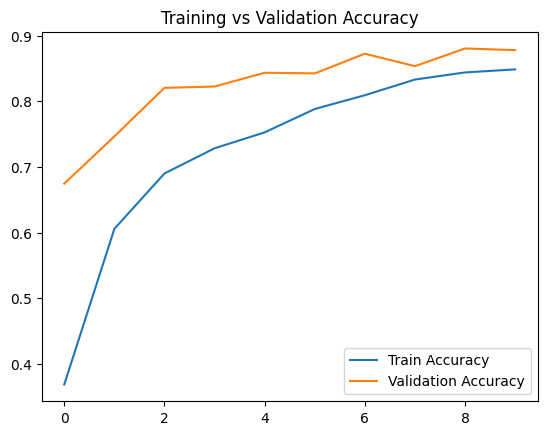

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()


In [ ]:
!pip install flask-ngrok


In [ ]:
import os
print(os.getcwd())  # Get the current working directory
print(os.listdir())  # List all files in the current directory

/content
['.config', '3-CercosporaLeaf1 (1).jpg', 'leaf_mold1.jpg', 'dataset', 'log.txt', 'app.py', 'tomato_disease_model.h5', 'early_blight1.jpg', 'archive (1).zip', '3-CercosporaLeaf1.jpg', 'sample_data']


In [ ]:
!pip install flask tensorflow


In [ ]:
pip install flask-cors


In [ ]:
from flask_cors import CORS


In [ ]:
!pip install pyngrok


In [14]:
app = Flask(__name__)
CORS(app)  # Enable CORS


NameError: name 'Flask' is not defined

In [13]:
public_url = ngrok.connect(5000)
print(" * ngrok tunnel running at:", public_url)


NameError: name 'ngrok' is not defined

In [ ]:
from flask import Flask, request, jsonify
from flask_cors import CORS
from pyngrok import ngrok
from PIL import Image
import numpy as np
import tensorflow as tf

app = Flask(__name__)
CORS(app)  # This allows cross-origin requests

# Load model, etc...


In [12]:
from flask import Flask, request, jsonify
from flask_cors import CORS
from pyngrok import ngrok
from PIL import Image
import numpy as np
import tensorflow as tf
import os

app = Flask(__name__)
CORS(app)  # Enable CORS for all routes

# Load the model only once
model_path = 'tomato_disease_model.h5'
if not os.path.exists(model_path):
    raise FileNotFoundError(f"Model file not found: {model_path}")
model = tf.keras.models.load_model(model_path)

# Class labels (Make sure the order matches the model output)
class_labels = [
    'Tomato___Bacterial_spot',
    'Tomato___Early_blight',
    'Tomato___Late_blight',
    'Tomato___Leaf_Mold',
    'Tomato___Septoria_leaf_spot',
    'Tomato___Spider_mites Two-spotted_spider_mite',
    'Tomato___Target_Spot',
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
    'Tomato___Tomato_mosaic_virus',
    'Tomato___healthy'
]

# Helper: Preprocess the image for prediction
def prepare_image(image):
    image = image.resize((224, 224))  # Make sure this matches your model's input
    image = np.array(image) / 255.0
    if image.shape[-1] == 4:
        image = image[..., :3]  # Convert RGBA to RGB
    image = np.expand_dims(image, axis=0)
    return image

@app.route('/predict', methods=['POST'])
def predict():
    if 'file' not in request.files:
        return jsonify({'error': 'No file part'})

    file = request.files['file']

    if file.filename == '':
        return jsonify({'error': 'No selected file'})

    try:
        image = Image.open(file.stream).convert('RGB')
        processed_image = prepare_image(image) q22qq
        prediction = model.predict(processed_image)
        predicted_label = class_labels[np.argmax(prediction)]
        return jsonify({'prediction': predicted_label})

    except Exception as e:
        return jsonify({'error': f'Prediction failed: {str(e)}'})

if __name__ == '__main__':
    # Start ngrok tunnel
    port = 5000
    public_url = ngrok.connect(port)
    print(" * ngrok tunnel running at:", public_url)

    # Start Flask app
    app.run(host='0.0.0.0', port=port, debug=False, threaded=True)


SyntaxError: invalid syntax (<ipython-input-12-2af7397fd4f9>, line 53)